In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn import preprocessing

import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.loadtxt("diabetes_binary_classification.txt")

# split into inputs and outputs
x, y = data[:, :-1], data[:, -1]

#scaling the input data
x = preprocessing.MinMaxScaler().fit_transform(x)

print ("x shape:", x.shape)
print ("y shape:", y.shape)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle = True, random_state=1)

print ("x_train shape:", x_train.shape)
print ("x_test shape:", x_test.shape)

x shape: (768, 8)
y shape: (768,)
x_train shape: (691, 8)
x_test shape: (77, 8)


### Defining, compiling and training the model

In [3]:
tf.keras.utils.set_random_seed(0)
    
model = keras.Sequential()
model.add(Dense(8, input_dim = x.shape[1], activation='relu', kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1, seed=None)))
model.add(Dense(4, activation='relu', kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1, seed=None)))
model.add(Dense(1, activation='sigmoid', kernel_initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1, seed=None)))
opt = tf.keras.optimizers.SGD(learning_rate=0.05)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['acc'])

history = model.fit(x_train, y_train, epochs=100, batch_size=64, validation_data =(x_test,y_test),verbose=0)

c:\Users\jorda\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Plotting model learning curves

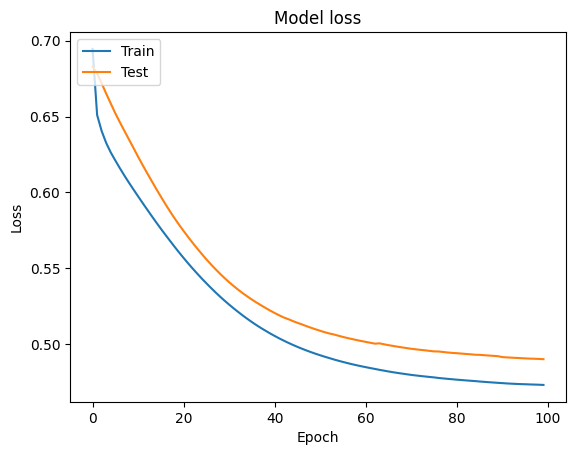

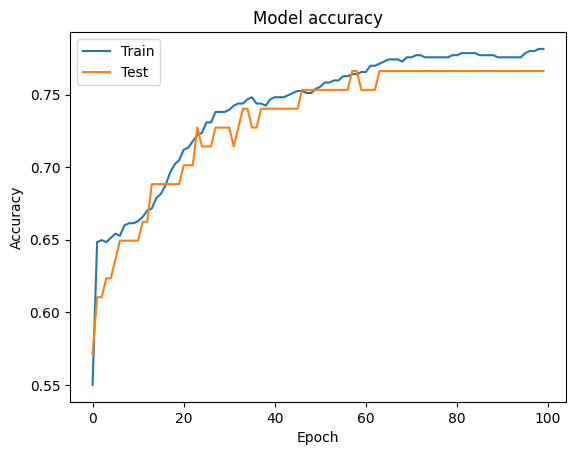

In [4]:
# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()